<a href="https://colab.research.google.com/github/AshrithSagar/CP260-RP-2025/blob/main/6_Lab_CP260_2025_Q.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Lab 6: Image Processing**

In this lab, you will do some basic image processing on the image of a number plate and then extract the characters using some off-the-shelf OCR (optical character recognition) tools.


In [ ]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
%%capture
!pip install gdown

In [ ]:
import gdown
url='https://drive.google.com/uc?id=1g_cBt642W8pXoLUzmzwcC1WEEbE-r5K5'
#url='https://drive.google.com/uc?id=1frpq1lnyIEzSntbyGcjg4-7b4c0c59md'
output='number_plate.jpg'
gdown.download(url, output, quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1g_cBt642W8pXoLUzmzwcC1WEEbE-r5K5
To: /content/number_plate.jpg
100%|██████████| 13.4k/13.4k [00:00<00:00, 18.4MB/s]


'number_plate.jpg'

(68, 178) 12104 uint8


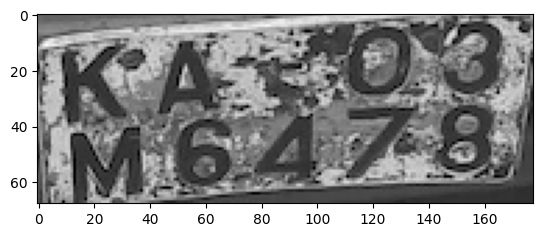

In [ ]:
img = cv.imread("number_plate.jpg", cv.IMREAD_GRAYSCALE)
plt.imshow(img, "gray")
print(img.shape, img.size, img.dtype)

---
**Q1**

Play around with different filters, kernel sizes and threshold values (for converting to binary), followed by morphological operators to get a satisfactory binary image, with as little noise as possible.


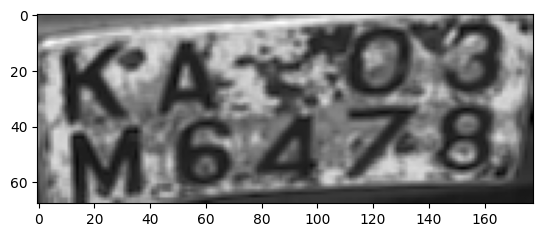

In [ ]:

#use your filter with appropriate kernel size adn parameter values
img_flt = <your code>
plt.imshow(img_flt,'gray')

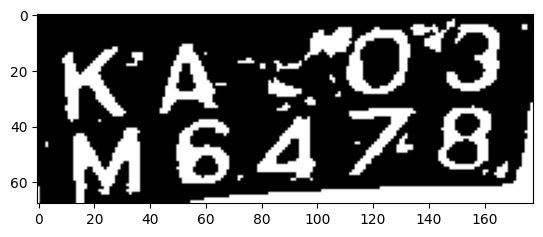

In [ ]:
#set your throeshold appropriately and convert the grayscale to binary image
thresh=<your code>
_,img_b=<your code>
plt.imshow(img_b,cmap='gray')

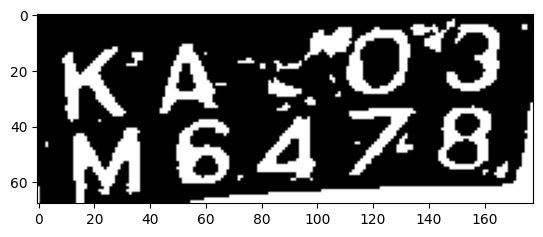

In [ ]:
#Check to see if any morphological operator gives any benefit
kernel = <your code>
img_open= <your code>
plt.imshow(img_open,cmap='gray')

In [ ]:
#identify connected components
<your code>

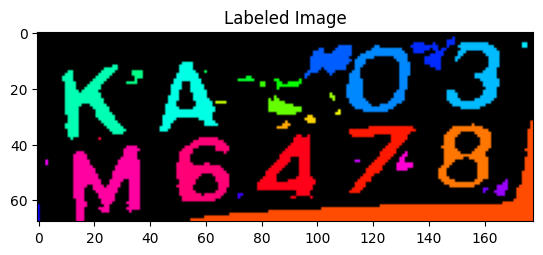

In [ ]:
# Create a color image to display the labeled components
label_hue = np.uint8(179 * labels / np.max(labels))
blank_ch = 255 * np.ones_like(label_hue)
labeled_img = cv.merge([label_hue, blank_ch, blank_ch])

# Convert to BGR for display
labeled_img = cv.cvtColor(labeled_img, cv.COLOR_HSV2BGR)

# Set background label to black
labeled_img[label_hue == 0] = 0

plt.imshow(labeled_img)
plt.title("Labeled Image")
plt.show()

---
**Q2**

Given the connected components, what filtering can you do to remove components that dont look like numbers (hint: e.g. size - read the documentation of connected components to understand what stats is)

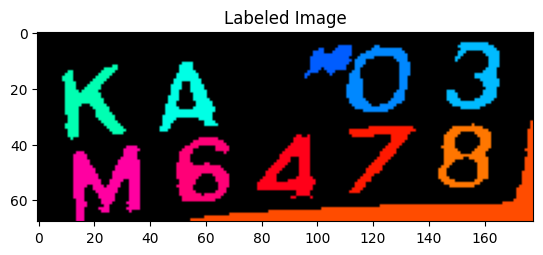

In [ ]:
for i in range(stats.shape[0]):
  <your code>

plt.imshow(labeled_img)
plt.title('Labeled Image')
plt.show()

---
**Q3**

Crop out the components so that they can be fed to a OCR tool.

You can first sort the components in the order needed for reading out the number plate.

In [ ]:
<your code>
print(stats_sorted)

[[   0    0  178   68 8962]
 [ 134    2   16   12   69]
 [ 147    4   19   24  192]
 [ 174    4    2    2    4]
 [  96    5   17   12  117]
 [ 111    5   23   24  228]
 [  44   11   21   25  225]
 [   9   12   23   27  253]
 [  32   14    6    5   16]
 [  60   14    1    1    1]
 [  72   16    6    2    8]
 [  85   17   10    4   19]
 [  80   18    2    2    4]
 [ 105   22    2    3    4]
 [  83   23   12    7   50]
 [  64   25    4    1    4]
 [ 107   28    2    2    3]
 [  96   30    4    3    9]
 [  55   32  123   36  682]
 [  86   32    5    3    8]
 [ 144   33   19   23  213]
 [ 112   34   24   24  173]
 [  79   37   21   23  222]
 [  22   38    1    1    1]
 [  50   38   19   23  245]
 [  13   41   24   27  335]
 [ 129   43    6    7   23]
 [   3   46    1    2    2]
 [ 114   46    2    1    2]
 [ 164   53    5    6   18]
 [ 160   56    2    2    3]
 [  72   58    2    2    3]
 [   0   62    1    6    6]]


In [ ]:
#Now crop out the components

<your code>

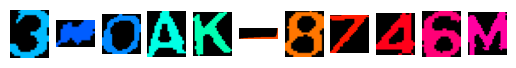

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=j)
for i in range(j):
    axes[i].imshow(crop[i])
    axes[i].axis("off")

In [ ]:
#rearrage to be able to read left to right and top to bottom
<your code>

5
[4, 3, 1, 2, 0]
[10, 9, 5, 8, 7, 6]
[12, 9, 7]
[11, 44, 6]
[5, 96, 2]
[5, 111, 3]
[4, 147, 4]
[41, 13, 25]
[38, 50, 24]
[32, 55, 20]
[37, 79, 22]
[34, 112, 21]
[33, 144, 19]


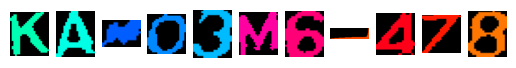

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=len(crop))
for i in range(len(crop)):
    axes[i].imshow(crop[sorted_id[i]])
    axes[i].axis("off")

---
**Q4**

Now we will run two differnt off-the-shelf OCR tools. We will
pass each of the cropped characters one by one and see the results.

We will also try sending the entire original image to see how well the OCR does.

In [ ]:
%%capture
!pip install easyocr

In [ ]:
import easyocr

In [ ]:
reader = easyocr.Reader(["en"])

In [ ]:
#pass each of the cropped images and see what it produces
for i in range(len(crop)):
  <your code>

K confidence= 0.9962229698317202
A confidence= 0.9931172953670853
3 confidence= 0.9998059366926668
M confidence= 0.9860906106102938
5 confidence= 0.11300158479485845
4 confidence= 0.873499545956836
8 confidence= 0.9997072434146048


In [ ]:
#apply it directly on the original image
<your code>

Ka409 confidence= 0.09838541436160203
M6478 confidence= 0.5925135799715455


In [ ]:
#apply it to the labelled image (after cleaning and segmentation)
<your code>

KA confidence= 0.9901507245076665
3 confidence= 0.501139887365624
M6478 , confidence= 0.33708674729939375


---
**Q5**

What is your observation?

**ANS**

<your answer>

---
**Q6**

We will try another OCR.

See if you can find the write parameter settings to get good results.

In [ ]:
%%capture
!sudo apt install tesseract-ocr
!pip install pytesseract

In [ ]:
import pytesseract
from PIL import Image

In [ ]:
for i in range(len(crop)):
<your code>

K

ray

Pi

8;

ie

Vi

=

|

A

f

3



---
**Reading**

https://blog.roboflow.com/best-ocr-models-text-recognition/

has a comparison of various OCR for accuracy and speed.

LLM based OCR work well but are heavy to use in an end-robot.